In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(
    "../data/cleaned/datapulse_sales_cleaned.csv"
)

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,order_date,customer_id,product,category,region,quantity,unit_price,discount,payment_method,returned,gross_sales,discount_amount,net_sales,year,month,month_name,day_name
0,O00001,2025-01-01 00:00:00.000000000,C0017,Headphones,Accessories,North,3,2500,0.00,Credit Card,No,7500,0.0,7500.0,2025,1,January,Wednesday
1,O00002,2025-01-01 02:36:59.483896779,C0056,Monitor,Electronics,East,4,15000,0.00,Credit Card,No,60000,0.0,60000.0,2025,1,January,Wednesday
2,O00003,2025-01-01 05:13:58.967793558,C0182,Laptop,Electronics,North,2,65000,0.05,Cash,No,130000,6500.0,123500.0,2025,1,January,Wednesday
3,O00004,2025-01-01 07:50:58.451690338,C0144,Laptop,Electronics,East,3,65000,0.10,Debit Card,No,195000,19500.0,175500.0,2025,1,January,Wednesday
4,O00005,2025-01-01 10:27:57.935587117,C0319,Laptop,Electronics,West,1,65000,0.00,Debit Card,No,65000,0.0,65000.0,2025,1,January,Wednesday


In [3]:
# Building the Customer-Level Dataset
customer_analysis = (
    df.groupby("customer_id")
      .agg(
          Revenue=("net_sales", "sum"),
          Orders=("order_id", "nunique"),
          Units=("quantity", "sum"),
          Average_Order_Value=("net_sales", "mean"),
          First_Order=("order_date", "min"),
          Last_Order=("order_date", "max")
      )
)

In [4]:
customer_analysis.head()

,Revenue,Orders,Units,Average_Order_Value,First_Order,Last_Order
customer_id,,,,,,
C0001,135820.0,7,20,19402.857143,2025-01-16 16:46:45.681136227,2026-05-16 15:04:30.054010800
C0002,300600.0,9,24,33400.000000,2025-02-15 11:05:24.784956991,2026-06-17 16:19:58.319663928
C0003,878500.0,13,35,67576.923077,2025-01-01 15:41:56.903380676,2026-06-12 21:12:21.028205640
C0004,1108185.0,16,43,69261.562500,2025-02-05 23:27:09.685937187,2026-05-05 09:34:23.212642528
C0005,100500.0,4,9,25125.000000,2025-05-30 21:43:10.358071614,2026-06-04 19:34:59.219843968


In [6]:
# How many customers?
total_customers = customer_analysis.shape[0]

print("Total Customers:", total_customers)

Total Customers: 500


In [7]:
df["customer_id"].nunique()

500

In [8]:
# Find the highest-value customers
top_customers = (
    customer_analysis
    .sort_values("Revenue", ascending=False)
    .head(10)
)

top_customers

,Revenue,Orders,Units,Average_Order_Value,First_Order,Last_Order
customer_id,,,,,,
C0410,1526130.0,15,56,101742.000000,2025-01-17 13:42:41.552310462,2026-03-27 03:37:29.009801960
C0127,1523575.0,13,42,117198.076923,2025-03-25 14:52:24.148829766,2026-06-23 05:46:31.998399680
C0307,1475130.0,11,36,134102.727273,2025-01-12 00:16:07.873574714,2026-06-23 16:14:29.933986792
C0159,1382975.0,22,65,62862.500000,2025-01-10 22:06:13.034606921,2026-06-22 00:59:37.675535104
C0215,1382075.0,13,48,106313.461538,2025-03-10 03:19:37.435487097,2026-06-04 01:16:02.832566512
C0300,1355175.0,14,41,96798.214286,2025-03-27 16:35:14.342868573,2026-05-23 19:45:55.991198240
C0456,1319975.0,20,60,65998.750000,2025-01-03 12:10:48.129625925,2026-06-21 14:31:39.739947984
C0050,1281650.0,12,43,106804.166667,2025-02-15 16:19:23.752750550,2026-04-23 22:50:17.403480696
C0275,1266725.0,15,52,84448.333333,2025-02-25 11:48:37.303460692,2026-06-17 00:38:01.416283256


In [9]:
top_customers[
    [
        "Revenue",
        "Orders",
        "Units",
        "Average_Order_Value"
    ]
]

,Revenue,Orders,Units,Average_Order_Value
customer_id,,,,
C0410,1526130.0,15,56,101742.000000
C0127,1523575.0,13,42,117198.076923
C0307,1475130.0,11,36,134102.727273
C0159,1382975.0,22,65,62862.500000
C0215,1382075.0,13,48,106313.461538
C0300,1355175.0,14,41,96798.214286
C0456,1319975.0,20,60,65998.750000
C0050,1281650.0,12,43,106804.166667
C0275,1266725.0,15,52,84448.333333


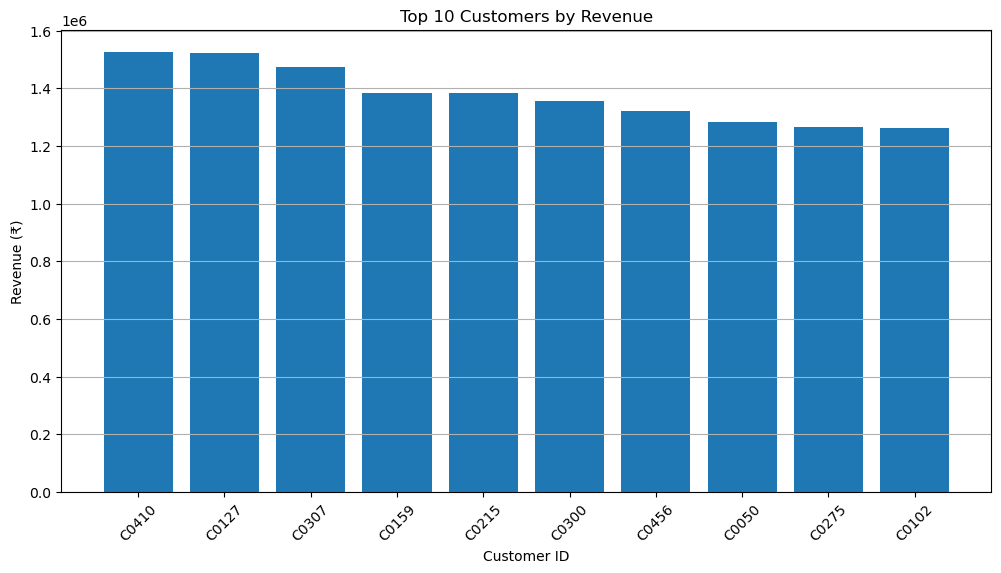

In [10]:
# Visualize Top 10 Customers
plt.figure(figsize=(12, 6))

plt.bar(
    top_customers.index.astype(str),
    top_customers["Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (₹)")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [11]:
# Customer Revenue Statistics
customer_analysis["Revenue"].describe()

count    5.000000e+02
mean     5.581886e+05
std      2.942488e+05
min      3.519000e+04
25%      3.398575e+05
50%      5.208650e+05
75%      7.443188e+05
max      1.526130e+06
Name: Revenue, dtype: float64

In [12]:
customer_median = customer_analysis["Revenue"].median()

print(
    "Median Customer Revenue: ₹",
    round(customer_median, 2)
)

Median Customer Revenue: ₹ 520865.0


In [13]:
customer_mean = customer_analysis["Revenue"].mean()

print(
    "Mean Customer Revenue: ₹",
    round(customer_mean, 2)
)

Mean Customer Revenue: ₹ 558188.6


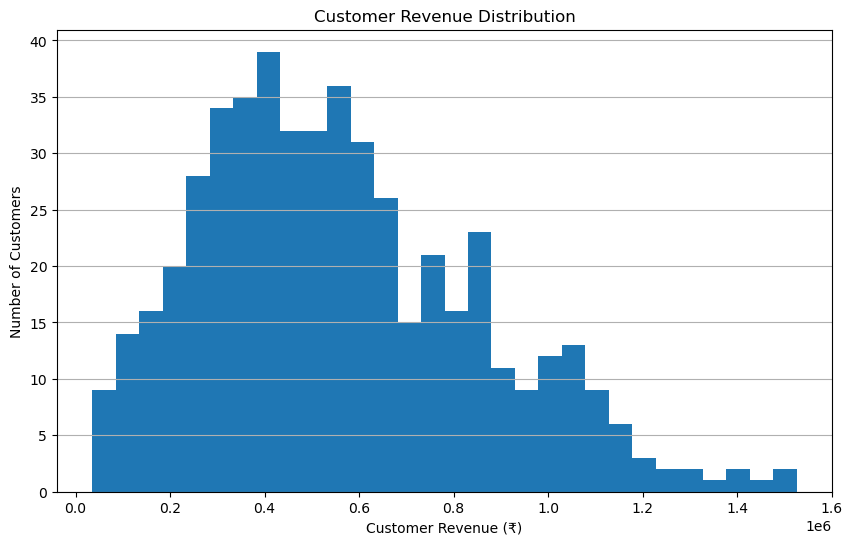

In [14]:
# Customer Revenue Distribution
plt.figure(figsize=(10, 6))

plt.hist(
    customer_analysis["Revenue"],
    bins=30
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue (₹)")
plt.ylabel("Number of Customers")

plt.grid(axis="y")

plt.show()

In [15]:
# Customer Segmentation by Revenue
customer_analysis["Revenue"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90]
)

count    5.000000e+02
mean     5.581886e+05
std      2.942488e+05
min      3.519000e+04
25%      3.398575e+05
50%      5.208650e+05
75%      7.443188e+05
90%      9.890695e+05
max      1.526130e+06
Name: Revenue, dtype: float64

In [20]:
# Analyzing the segments
# Create the missing customer segment column before grouping
customer_analysis["Customer_Segment"] = pd.cut(
    customer_analysis["Revenue"],
    bins=[0, customer_median, customer_mean, float("inf")],
    labels=["Low Value", "Medium Value", "High Value"],
    include_lowest=True
)

segment_analysis = (
    customer_analysis
    .groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("Revenue", "count"),
        Revenue=("Revenue", "sum"),
        Average_Revenue=("Revenue", "mean"),
        Average_Orders=("Orders", "mean")
    )
)

In [21]:
# Pareto Analysis
customer_pareto = (
    customer_analysis
    .sort_values("Revenue", ascending=False)
    .copy()
)

In [22]:
customer_pareto["Cumulative_Revenue"] = (
    customer_pareto["Revenue"].cumsum()
)

In [23]:
customer_pareto["Cumulative_Revenue_Percentage"] = (
    customer_pareto["Cumulative_Revenue"]
    / customer_pareto["Revenue"].sum()
    * 100
)

In [24]:
# customers responsible for 80% of revenue
customers_for_80_percent = (
    customer_pareto[
        customer_pareto["Cumulative_Revenue_Percentage"] <= 80
    ]
    .shape[0]
)

In [25]:
customer_percentage = (
    customers_for_80_percent
    / customer_pareto.shape[0]
    * 100
)

print(
    "Customers contributing up to 80% of revenue:",
    customers_for_80_percent
)

print(
    "Percentage of customers:",
    round(customer_percentage, 2),
    "%"
)

Customers contributing up to 80% of revenue: 302
Percentage of customers: 60.4 %


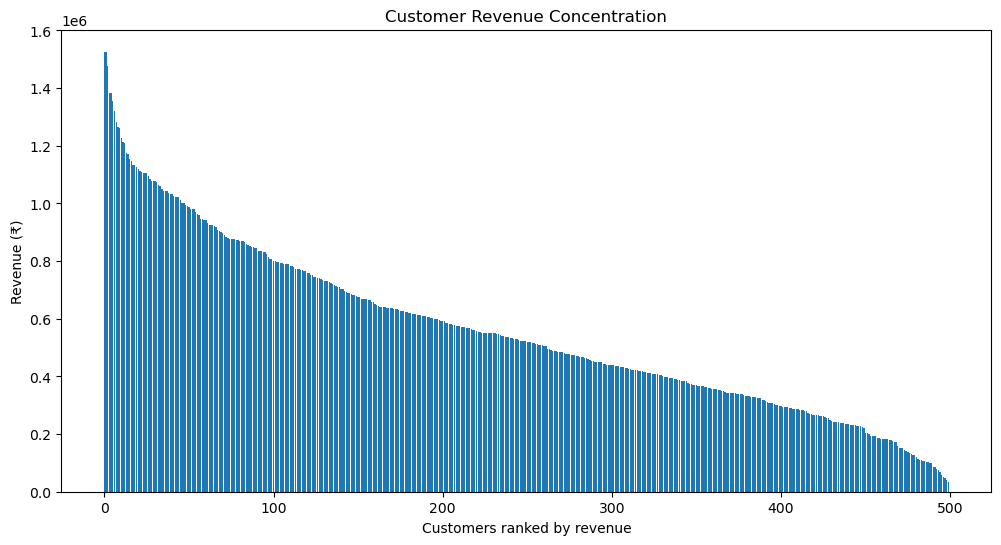

In [26]:
# Pareto Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(
    range(len(customer_pareto)),
    customer_pareto["Revenue"]
)

ax1.set_xlabel("Customers ranked by revenue")
ax1.set_ylabel("Revenue (₹)")

ax1.set_title("Customer Revenue Concentration")

plt.show()

#  Day 10 — Customer Analytics Insights

## Customer Overview

- Total customers: **500**
- Average customer revenue: **₹558,188.60**
- Median customer revenue: **₹520,865.00**
- Repeat customer rate: **Not calculated**

## Top Customers

The highest-value customer generated **₹1,526,130** in revenue.

The top customers generally showed **high revenue contribution, with several customers generating over ₹1.2 million in total revenue**.

## Customer Segmentation

The High Value segment contains **[calculate from segment_analysis]** customers

and contributes **[calculate from segment_analysis]**% of total revenue.

The Low Value segment contains **[calculate from segment_analysis]** customers

and contributes **[calculate from segment_analysis]**% of total revenue.

## Revenue Concentration

The analysis found that approximately **60.4% of customers** contribute up to 80% of revenue.

This suggests that revenue is **moderately concentrated** among a relatively smaller group of customers.

## Repeat Purchasing

The repeat customer rate is **not calculated in the current analysis**.

This indicates that **repeat purchasing behavior still needs to be measured to fully understand customer retention and loyalty**.

## Key Business Insight

The most important customer-level finding is:

**Revenue is meaningfully concentrated among higher-value customers: around 60.4% of customers account for up to 80% of total revenue, highlighting the importance of retaining and growing high-value customers.**

In [27]:
customer_analysis.to_csv(
    "../data/processed/customer_analysis.csv"
)

In [28]:
segment_analysis.to_csv(
    "../data/processed/customer_segments.csv"
)